# YouTube Channel Analytics — privacy-safe charts

**Self-directed analysis of real YouTube channel performance data (the specific channel is kept private).** This notebook charts **rates and percentages only** — CTR %, % change, and indexes. It never displays raw views, impressions, or subscriber counts.

It runs on a small **synthetic sample** (`data/sample_synthetic.csv`) so it works out of the box. To run it on your own data, drop your export in `data/private/` (git-ignored) and re-run `import_to_sqlite.py`.

In [1]:
%matplotlib inline
import sqlite3, subprocess, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DB = Path('data/youtube.db')
if not DB.exists():
    subprocess.run([sys.executable, 'import_to_sqlite.py'], check=True)
con = sqlite3.connect(DB)

def q(name):
    """Run a .sql file from queries/ and return a DataFrame."""
    return pd.read_sql_query(Path('queries', name).read_text(encoding='utf-8'), con)

Path('images').mkdir(exist_ok=True)
ORDER = ['Before', 'After']
plt.rcParams['figure.figsize'] = (6, 4)

## Impressions-weighted CTR: Before vs After
The headline measure — each video weighted by how often it was shown.

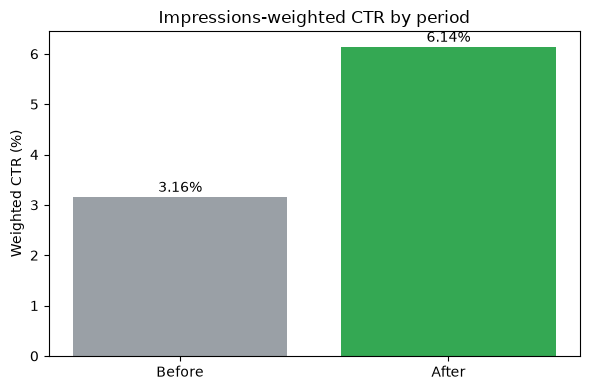

In [2]:
df = q('01_weighted_ctr_by_period.sql').set_index('period').loc[ORDER].reset_index()
plt.bar(df['period'], df['weighted_ctr_percent'], color=['#9aa0a6', '#34a853'])
plt.ylabel('Weighted CTR (%)'); plt.title('Impressions-weighted CTR by period')
for i, v in enumerate(df['weighted_ctr_percent']):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center')
plt.tight_layout(); plt.savefig('images/weighted_ctr_by_period.png', dpi=120); plt.show()

## Weighted CTR trend by month

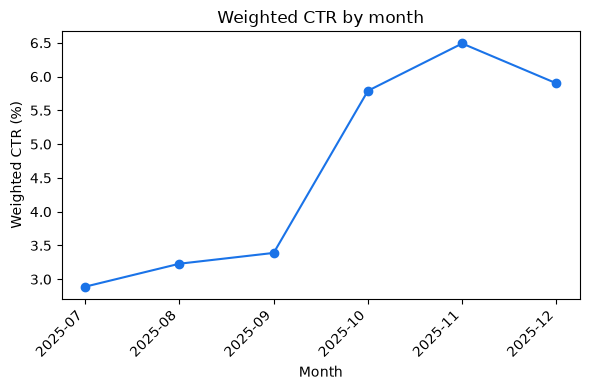

In [3]:
m = q('04_weighted_ctr_by_month.sql')
plt.plot(m['month'], m['weighted_ctr_percent'], marker='o', color='#1a73e8')
plt.ylabel('Weighted CTR (%)'); plt.xlabel('Month'); plt.title('Weighted CTR by month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('images/weighted_ctr_by_month.png', dpi=120); plt.show()

## Views per video — index (Before = 100)
Shown as an index so the relative jump is visible without exposing any raw view count.

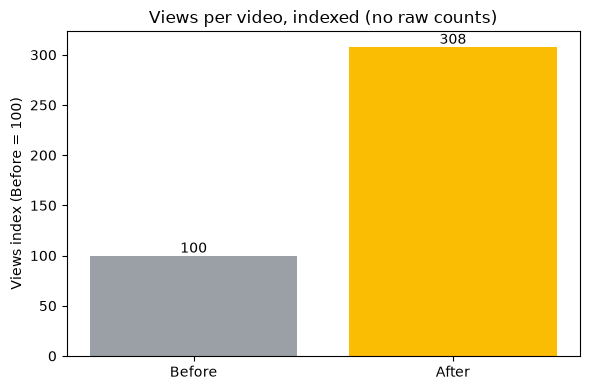

In [4]:
vi = q('06_views_index_by_period.sql').set_index('period').loc[ORDER].reset_index()
plt.bar(vi['period'], vi['views_index_before_100'], color=['#9aa0a6', '#fbbc04'])
plt.ylabel('Views index (Before = 100)'); plt.title('Views per video, indexed (no raw counts)')
for i, v in enumerate(vi['views_index_before_100']):
    plt.text(i, v + 3, f'{v:.0f}', ha='center')
plt.tight_layout(); plt.savefig('images/views_index_by_period.png', dpi=120); plt.show()

## Reading the charts

On this **synthetic sample**, impressions-weighted CTR roughly doubles after the change date (~3.2% → ~6.1%) and views jump to ~3× their prior level — that is the *pattern* this method is built to surface. On my real channel the same model showed a comparable story: a **~96% weighted-CTR lift**, reported in rate terms only (see the project README). The honest caveats apply either way — the split is data-detected, a viral outlier can skew averages (impressions-weighting tempers it), upload volume shifts across the window, and an AI-launch seasonality bump can share credit. Absolute counts stay in a private one-pager; this notebook is rates-only.